# Helpers

In [2]:
import os
import json

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

In [4]:
def create_item_id(df):
    cols_a = [col for col in df.columns if "a_" in col]
    cols_b = [col.replace('a_','b_') for col in cols_a]
    df['item_a'] = df.apply(lambda row: '-'.join([row[colname] for colname in cols_a]), axis=1)
    df['item_b'] = df.apply(lambda row: '-'.join([row[colname] for colname in cols_b]), axis=1)
    return df


def create_item_mapping(df_raw_scores: pd.DataFrame,
                        item_i_col='option_a',
                        item_j_col='option_b') -> dict:
    """Maps unique string items to integer indices 0 to N-1."""
    items = pd.concat([df_raw_scores[item_i_col], df_raw_scores[item_j_col]]).unique()
    return {item: idx for idx, item in enumerate(sorted(items))}

def fit_bradley_terry_statsmodels(df: pd.DataFrame, item_mapping: dict, 
                              item_i_col='option_a', item_j_col='option_b',
                              score_a_col='score_a', score_b_col='score_b') -> dict:
    """
    Fits the Bradley-Terry model with Positional Bias and returns a structured dictionary.
    """
    n_samples = len(df)
    n_items = len(item_mapping)
    
    # 1. Target Variable Y (Log-Odds)
    Y = (df[score_a_col] - df[score_b_col]).values
    
    # 2. Design Matrix X
    X_base = np.zeros((n_samples, n_items))
    i_indices = df[item_i_col].map(item_mapping).values
    j_indices = df[item_j_col].map(item_mapping).values
    
    row_indices = np.arange(n_samples)
    X_base[row_indices, i_indices] = 1
    X_base[row_indices, j_indices] = -1
    
    # Drop the last item column to avoid perfect multicollinearity
    X_base = X_base[:, :-1] 
    
    # Add the Intercept for gamma (Positional Bias)
    X = sm.add_constant(X_base) 
    
    # 3. Fit the OLS Model
    model = sm.OLS(Y, X)
    results = model.fit()
    
    # 4. Extract Bias and P-Value
    # 'const' is always at index 0 in statsmodels when using add_constant
    gamma_bias = results.params[0]
    gamma_pvalue = results.pvalues[0]
    
    # 5. Extract and format Item Scores
    # The coefficients for the items start at index 1. 
    # We append a 0.0 for the reference item we dropped earlier.
    raw_item_scores = np.append(results.params[1:], 0.0)
    
    # Mean-center the scores so they are centered around 0 (standard for BT models)
    centered_scores = raw_item_scores - np.mean(raw_item_scores)
    
    # Reverse the mapping to get {index: 'ItemName'}
    idx_to_item = {idx: item for item, idx in item_mapping.items()}
    
    # Create a dictionary of {ItemName: Score}
    item_scores_dict = {idx_to_item[i]: score for i, score in enumerate(centered_scores)}
    
    # 6. Compile the final dictionary
    output_dict = {
        "item_scores": item_scores_dict,
        "positional_bias_gamma": gamma_bias,
        "gamma_pvalue": gamma_pvalue,
        "model_r_squared": results.rsquared, # Good to keep for diagnostics!
        "f_stat_pvalue": results.f_pvalue    # Tests if the whole model is significant
    }
    
    return output_dict

def fit_feature_based_bradley_terry(df: pd.DataFrame, 
                                    a_prefix='a_', b_prefix='b_',
                                    score_a_col='score_a', score_b_col='score_b') -> dict:
    """
    Fits a Feature-Based Bradley-Terry model with Positional Bias.
    Automatically detects categorical features and handles dummy encoding.
    """
    n_samples = len(df)
    
    # 1. Target Variable Y (Log-Odds)
    Y = (df[score_a_col] - df[score_b_col]).values
    
    # 2. Automatically detect feature columns
    cols_a = [col for col in df.columns if col.startswith(a_prefix)]
    cols_b = [col.replace(a_prefix, b_prefix) for col in cols_a]
    
    # Extract the base feature names (e.g., 'a_brand' -> 'brand')
    base_features = [col[len(a_prefix):] for col in cols_a]
    
    # 3. Standardize and align the feature sets
    # We rename the columns so both A and B share the exact same column names
    df_a = df[cols_a].rename(columns=dict(zip(cols_a, base_features)))
    df_b = df[cols_b].rename(columns=dict(zip(cols_b, base_features)))
    
    # Combine A and B vertically. This is crucial! 
    # It ensures that pd.get_dummies() sees all possible categories across the entire 
    # dataset and drops the EXACT SAME reference level for both Option A and Option B.
    df_combined = pd.concat([df_a, df_b], axis=0)
    
    # Create dummy variables (dropping the first level to avoid multicollinearity)
    # We cast to float to ensure statsmodels handles it cleanly
    df_combined_dummies = pd.get_dummies(df_combined, drop_first=True, dtype=float)
    
    # Split them back apart into A and B matrices
    dummies_a = df_combined_dummies.iloc[:n_samples]
    dummies_b = df_combined_dummies.iloc[n_samples:]
    
    # 4. Create the Design Matrix X (Features A - Features B)
    X_base = dummies_a.values - dummies_b.values
    feature_names = dummies_a.columns.tolist()
    
    # Add the Intercept for gamma (Positional Bias)
    X = sm.add_constant(X_base)
    
    # 5. Fit the OLS Model
    model = sm.OLS(Y, X)
    results = model.fit()
    
    # 6. Extract Bias
    gamma_bias = results.params[0]
    gamma_pvalue = results.pvalues[0]
    
    # 7. Extract Feature Utilities (Weights)
    # Coefficients start at index 1 (index 0 is the intercept)
    feature_weights = results.params[1:]
    feature_pvalues = results.pvalues[1:]
    
    # Create dictionaries mapping the specific feature category to its learned utility
    feature_scores_dict = {feat: weight for feat, weight in zip(feature_names, feature_weights)}
    feature_pvalues_dict = {feat: pval for feat, pval in zip(feature_names, feature_pvalues)}
    
    # 8. Compile the final dictionary
    output_dict = {
        "feature_scores": feature_scores_dict,
        "feature_pvalues": feature_pvalues_dict,
        "positional_bias_gamma": gamma_bias,
        "gamma_pvalue": gamma_pvalue,
        "model_r_squared": results.rsquared, 
        "f_stat_pvalue": results.f_pvalue    
    }
    
    return output_dict

# Robustness New

In [16]:
basedir = 'data/laptops_robustness'
scores_df = pd.DataFrame()
for filename in os.listdir(basedir):
    config_path = os.path.join(basedir, filename, 'config.json')
    if not os.path.isfile(config_path):
        continue
    with open(config_path, 'r') as f:
        config = json.load(f)
    model_size = config['model_size']
    constraints = config.get('constraints', None)
    print(f"{filename}: model_size={model_size}, constraints={constraints}")

    df = pd.read_csv(os.path.join(basedir,filename,'scores.csv'))
    results = fit_feature_based_bradley_terry(df)
    scores = results['feature_scores']
    scores_df[f'{model_size}-{constraints}'] = pd.Series(scores)
    # for k, v in results['feature_scores'].items():
    #     print(f"{k}: {v}")
    
    # break
scores_df.head()

68337596: model_size=7, constraints=14
68339918: model_size=0.5, constraints=14
68339919: model_size=32, constraints=14
68339920: model_size=72, constraints=14
68373840: model_size=7, constraints=
68373841: model_size=32, constraints=


,7-14,0.5-14,32-14,72-14,7-,32-
brand_Apple,-1.278200,-0.053367,-0.362996,-0.384317,0.121262,1.603729
brand_Dell,-0.505418,-0.023996,-1.043895,0.563759,-0.475085,-1.450316
brand_HP,-0.419438,0.020046,-1.468046,-0.124309,-0.623505,-2.211476
brand_Lenovo,-0.319602,-0.038394,-0.464867,-0.060016,-0.736970,-0.975595
screen_14-inch,8.546114,0.451930,18.093051,15.610703,1.702385,2.805594


In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

def plot_preference_shift(df: pd.DataFrame, 
                          feature_col: str = 'Brand',
                          w_base_col: str = 'Weight_32_Base', 
                          p_base_col: str = 'Pval_32_Base',
                          w_constrained_col: str = 'Weight_32_14', 
                          p_constrained_col: str = 'Pval_32_14'):
    """
    Plots the shift in LLM latent utility weights between an unconstrained 
    and constrained condition. Automatically fades bars that are not 
    statistically significant (p > 0.05).
    """
    fig, ax = plt.subplots(figsize=(10, 6))
    
    # Setup X-axis positions
    x = np.arange(len(df))
    width = 0.35  
    
    # Define primary colors
    color_base = '#1f77b4'      # Deep Blue
    color_constrained = '#ff7f0e' # Bright Orange
    
    # Significance threshold
    alpha_sig = 1.0  # Solid color if significant
    alpha_insig = 0.25 # Faded color if mostly noise (p > 0.05)

    # Plot each bar individually so we can apply specific opacity based on p-value
    for i in range(len(df)):
        # Base Condition (32-)
        alpha1 = alpha_sig if df.loc[i, p_base_col] <= 0.05 else alpha_insig
        ax.bar(x[i] - width/2, df.loc[i, w_base_col], width, 
               color=color_base, alpha=alpha1, edgecolor='black', linewidth=0.5)
        
        # Constrained Condition (32-14)
        alpha2 = alpha_sig if df.loc[i, p_constrained_col] <= 0.05 else alpha_insig
        ax.bar(x[i] + width/2, df.loc[i, w_constrained_col], width, 
               color=color_constrained, alpha=alpha2, edgecolor='black', linewidth=0.5)

    # Add a horizontal zero-line for the baseline reference
    ax.axhline(0, color='black', linewidth=1.2, linestyle='-')

    # Formatting and Labels
    ax.set_ylabel('Latent Utility (Log-Odds Weight)', fontsize=12, fontweight='bold')
    ax.set_title('Preference Flattening: Impact of "14-inch" Constraint on Brand Bias', 
                 fontsize=14, pad=15)
    
    ax.set_xticks(x)
    ax.set_xticklabels(df[feature_col], rotation=45, ha='right', fontsize=11)
    
    # Custom Legend
    legend_elements = [
        Patch(facecolor=color_base, label='Unconstrained (32GB RAM)', alpha=alpha_sig),
        Patch(facecolor=color_constrained, label='Constrained (+14-inch Screen)', alpha=alpha_sig),
        Patch(facecolor='gray', label='Not Significant (p > 0.05)', alpha=alpha_insig)
    ]
    ax.legend(handles=legend_elements, loc='upper right', framealpha=0.9)

    plt.tight_layout()
    plt.show()


Loaded 68339919 -> 32-14
Loaded 68373841 -> 32-


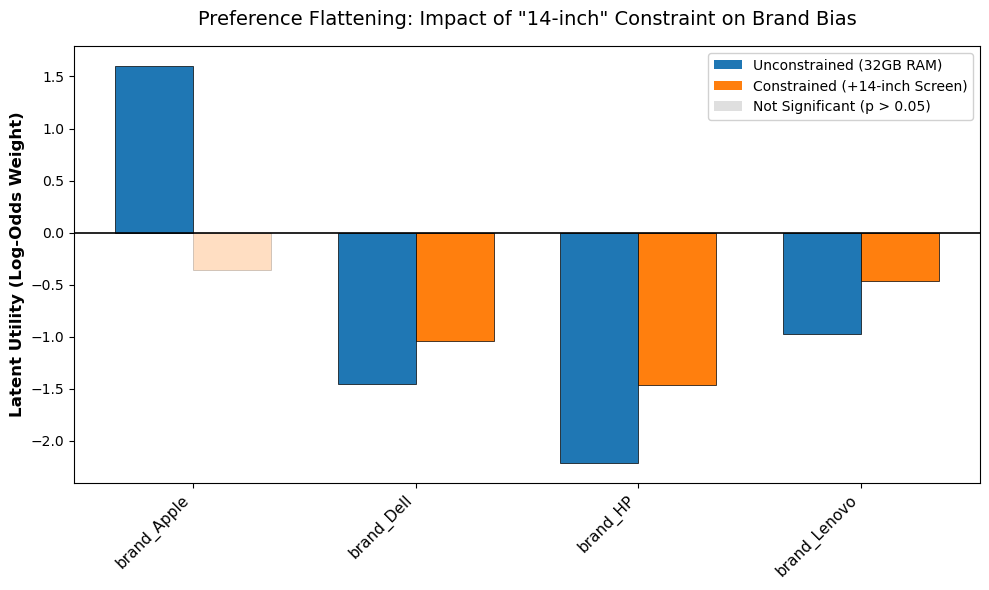

In [24]:
import os
import json
import pandas as pd

basedir = 'data/laptops_robustness'

# 1. Initialize dictionaries to hold both weights and p-values
weights_dict = {}
pvalues_dict = {}

for filename in os.listdir(basedir):
    config_path = os.path.join(basedir, filename, 'config.json')
    if not os.path.isfile(config_path):
        continue
        
    with open(config_path, 'r') as f:
        config = json.load(f)
        
    model_size = config.get('model_size', '')
    
    # Safely format the constraint string (convert None to empty string)
    constraints = config.get('constraints', '') 
    if constraints is None:
        constraints = ''
        
    run_key = f"{model_size}-{constraints}"
    
    # We only care about parsing these two specific runs for the plot
    if run_key not in ['32-', '32-14']:
        continue

    print(f"Loaded {filename} -> {run_key}")

    # Load data and fit model
    df = pd.read_csv(os.path.join(basedir, filename, 'scores.csv'))
    results = fit_feature_based_bradley_terry(df)
    
    # 2. Store BOTH the weights and the p-values
    weights_dict[run_key] = results['feature_scores']
    pvalues_dict[run_key] = results['feature_pvalues']

# --- Assemble the Final DataFrame for Plotting ---

# Convert the dictionaries to pandas DataFrames
df_weights = pd.DataFrame(weights_dict)
df_pvalues = pd.DataFrame(pvalues_dict)

# 3. Combine them into the exact format expected by the plotting function
plot_df = pd.DataFrame({
    'Feature': df_weights.index,
    'Weight_32_Base': df_weights['32-'].values,
    'Pval_32_Base': df_pvalues['32-'].values,
    'Weight_32_14': df_weights['32-14'].values,
    'Pval_32_14': df_pvalues['32-14'].values
})

# OPTIONAL: If your model fits weights for RAM, CPU, etc., and you ONLY 
# want to plot the Brand preference shift, uncomment this line:
plot_df = plot_df[plot_df['Feature'].str.startswith('brand_')].reset_index(drop=True)

# 4. Call the visualizer
plot_preference_shift(
    df=plot_df, 
    feature_col='Feature',
    w_base_col='Weight_32_Base', 
    p_base_col='Pval_32_Base',
    w_constrained_col='Weight_32_14', 
    p_constrained_col='Pval_32_14'
)

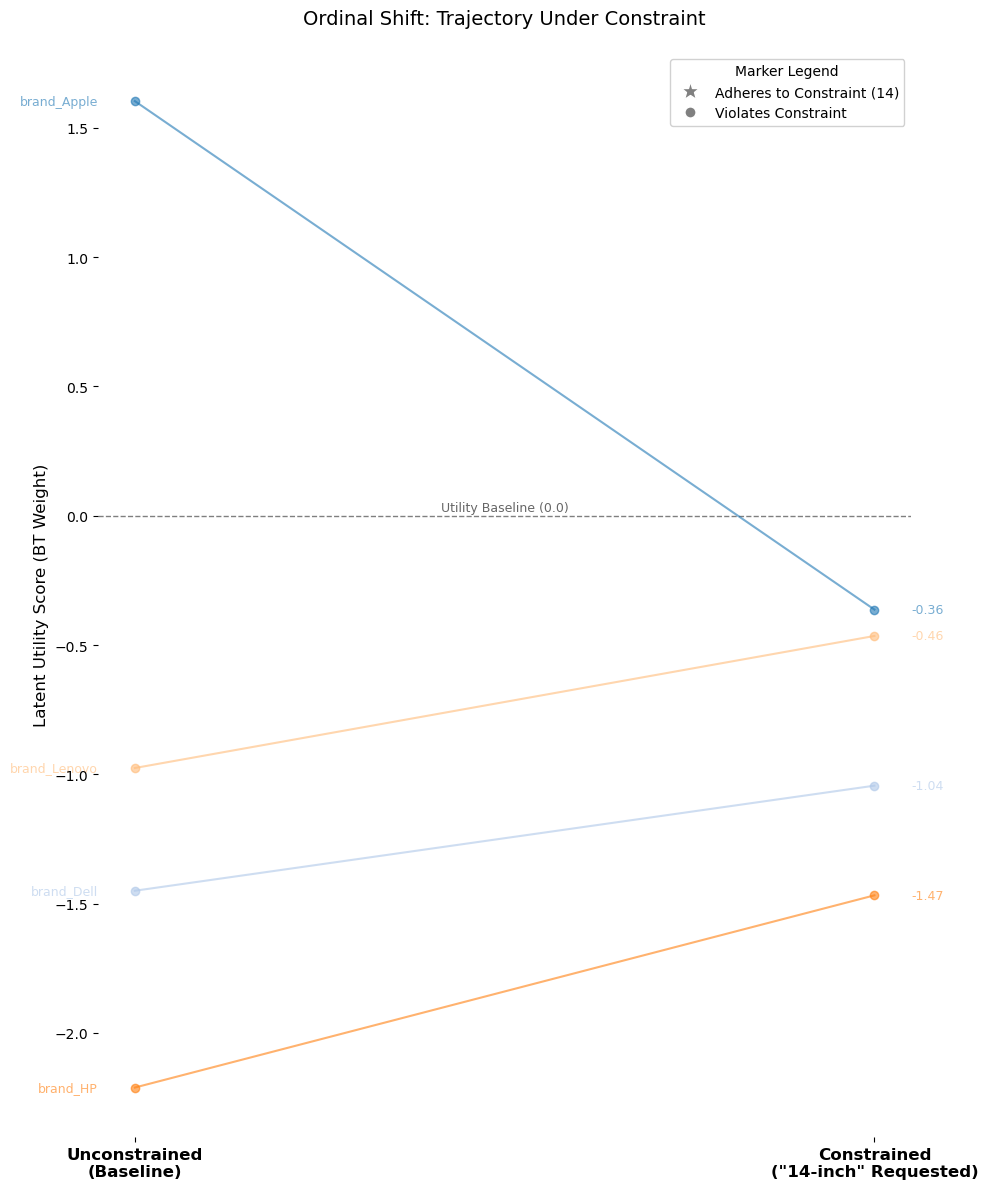

In [26]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import pandas as pd
from matplotlib.lines import Line2D

def plot_item_slope_graph_colorful(df: pd.DataFrame, 
                                   item_col: str = None, 
                                   val_left: str = 'Weight_32_Base',
                                   val_right: str = 'Weight_32_14',
                                   constraint_target: str = '14'):
    """
    Creates a colorful Slope Graph tracking individual item trajectories.
    Automatically detects the item column to prevent KeyErrors.
    """
    # FIX: Auto-detect the label column if none is provided
    if item_col is None:
        item_col = df.columns[0]
        
    fig, ax = plt.subplots(figsize=(10, 12))
    x_coords = [0, 1]
    
    # FIX: Modern Matplotlib colormap calling convention
    cmap = mpl.colormaps['tab20']
    
    for i, row in df.iterrows():
        item_name = str(row[item_col])
        y_coords = [row[val_left], row[val_right]]
        
        # Check if this specific item adheres to the constraint
        is_target = constraint_target in item_name 
        
        # Unique Color per Item
        color = cmap(i % 20) 
        
        # Marker represents constraint adherence
        marker = '*' if is_target else 'o'
        markersize = 12 if is_target else 6
        
        linewidth = 3.0 if is_target else 1.5
        alpha = 0.95 if is_target else 0.6
        zorder = 3 if is_target else 1
        font_weight = 'bold' if is_target else 'normal'
        
        # Plot the trajectory line
        ax.plot(x_coords, y_coords, color=color, alpha=alpha, 
                linewidth=linewidth, marker=marker, markersize=markersize, zorder=zorder)
        
        # Add labels to the left and right of the points
        ax.text(-0.05, y_coords[0], item_name, ha='right', va='center', 
                fontsize=9, color=color, alpha=alpha, zorder=zorder, fontweight=font_weight)
        ax.text(1.05, y_coords[1], f"{row[val_right]:.2f}", ha='left', va='center', 
                fontsize=9, color=color, alpha=alpha, zorder=zorder, fontweight=font_weight)

    # Styling the axes
    ax.set_xticks([0, 1])
    ax.set_xticklabels(['Unconstrained\n(Baseline)', 'Constrained\n("14-inch" Requested)'], 
                       fontsize=12, fontweight='bold')
    
    # Remove plot borders
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_visible(False)
    ax.spines['left'].set_visible(False)
    
    # Add a subtle zero-line
    ax.axhline(0, color='black', linewidth=1, linestyle='--', alpha=0.5, zorder=0)
    ax.text(0.5, 0.02, 'Utility Baseline (0.0)', ha='center', fontsize=9, alpha=0.6)

    # Custom Legend
    legend_elements = [
        Line2D([0], [0], marker='*', color='w', label=f'Adheres to Constraint ({constraint_target})', 
               markerfacecolor='gray', markersize=14),
        Line2D([0], [0], marker='o', color='w', label='Violates Constraint', 
               markerfacecolor='gray', markersize=8)
    ]
    ax.legend(handles=legend_elements, loc='upper right', framealpha=0.9, title="Marker Legend")

    ax.set_ylabel('Latent Utility Score (BT Weight)', fontsize=12)
    ax.set_title('Ordinal Shift: Trajectory Under Constraint', fontsize=14, pad=20)
    
    plt.tight_layout()
    plt.show()

# Execution Call
plot_item_slope_graph_colorful(plot_df)

In [ ]:
import os
import json

def fit_bt(df):
    df = create_item_id(df)
    mapping = create_item_mapping(df, 'item_a','item_b')
    bt_scores = fit_bradley_terry_statsmodels(df, mapping, 'item_a', 'item_b')
    return bt_scores['item_scores']

basedir = 'data/eos_fix_qwen'
baseline = {}
for filename in os.listdir(basedir):
    with open(os.path.join(basedir,filename,'config.json'), 'r') as f:
        config = json.load(f)
    model_size = config['model_size']
    if config['alternatives'] != 'laptop_brands':
        continue

    df = pd.read_csv(os.path.join(basedir,filename,'scores.csv'))
    mapping = create_item_mapping(df)
    bt_scores = fit_bradley_terry_statsmodels(df, mapping)['item_scores']    
    baseline[model_size] = bt_scores

baseline_df = pd.DataFrame(baseline)
# print(baseline_df)
results_one, results_both, results_none = {}, {}, {}

basedir = 'data/laptops_robustness'
for filename in os.listdir(basedir):
    with open(os.path.join(basedir,filename,'config.json'), 'r') as f:
        config = json.load(f)
    model_size = config['model_size']

    df = pd.read_csv(os.path.join(basedir,filename,'scores.csv'))
    con = '14-inch'
    
    df_none = df[(df['a_screen'] != con) & (df['b_screen'] != con)]
    df_both = df[(df['a_screen'] == con) & (df['b_screen'] == con)]
    df_one = df[((df['a_screen'] == con) & (df['b_screen'] != con)) | ((df['a_screen']!=con)&df['b_screen']==con)]


    results_one[model_size] = fit_bt(df_one)
    results_none[model_size] = fit_bt(df_none)
    results_both[model_size] = fit_bt(df_both)

/tmp/ipykernel_228988/3874252891.py:39: Pandas4Warning: 'and' operations between boolean dtype and str are deprecated and will raise in a future version. Explicitly cast the strings to a boolean dtype before operating instead.
  df_one = df[((df['a_screen'] == con) & (df['b_screen'] != con)) | ((df['a_screen']!=con)&df['b_screen']==con)]


(4350, 1050, 2250)


/tmp/ipykernel_228988/3874252891.py:39: Pandas4Warning: 'and' operations between boolean dtype and str are deprecated and will raise in a future version. Explicitly cast the strings to a boolean dtype before operating instead.
  df_one = df[((df['a_screen'] == con) & (df['b_screen'] != con)) | ((df['a_screen']!=con)&df['b_screen']==con)]


(4350, 1050, 2250)


/tmp/ipykernel_228988/3874252891.py:39: Pandas4Warning: 'and' operations between boolean dtype and str are deprecated and will raise in a future version. Explicitly cast the strings to a boolean dtype before operating instead.
  df_one = df[((df['a_screen'] == con) & (df['b_screen'] != con)) | ((df['a_screen']!=con)&df['b_screen']==con)]
/tmp/ipykernel_228988/3874252891.py:39: Pandas4Warning: 'and' operations between boolean dtype and str are deprecated and will raise in a future version. Explicitly cast the strings to a boolean dtype before operating instead.
  df_one = df[((df['a_screen'] == con) & (df['b_screen'] != con)) | ((df['a_screen']!=con)&df['b_screen']==con)]


(4350, 1050, 2250)
(4350, 1050, 2250)


In [31]:
pd.Series(baseline_df['32']).sort_values(ascending=False)

Apple     8.911315
ASUS      4.970363
Lenovo   -2.546279
Dell     -4.328605
HP       -7.006795
Name: 32, dtype: float64

In [29]:
pd.Series(results_both['32']).sort_values(ascending=False)

Apple-14-inch-16GB     21.319193
ASUS-14-inch-16GB      19.117637
Lenovo-14-inch-16GB    17.550695
Dell-14-inch-16GB      17.331938
HP-14-inch-16GB        15.185098
Apple-14-inch-8GB       4.867767
ASUS-14-inch-8GB        1.947588
Lenovo-14-inch-8GB      0.408506
Dell-14-inch-8GB       -0.347936
HP-14-inch-8GB         -2.090830
Apple-14-inch-4GB     -17.411022
ASUS-14-inch-4GB      -18.256523
Lenovo-14-inch-4GB    -19.210029
Dell-14-inch-4GB      -19.791991
HP-14-inch-4GB        -20.620090
dtype: float64

In [32]:
pd.Series(results_one['32']).sort_values(ascending=False)

Lenovo-14-inch-16GB     7.890496
ASUS-14-inch-16GB       7.787527
Dell-14-inch-16GB       7.747423
HP-14-inch-16GB         7.289559
Apple-13-inch-16GB      6.930103
Apple-14-inch-16GB      6.833257
ASUS-13-inch-16GB       6.382316
Apple-16-inch-16GB      6.341978
Lenovo-13-inch-16GB     5.412870
Dell-13-inch-16GB       5.266053
Lenovo-14-inch-8GB      5.139904
ASUS-14-inch-8GB        5.103143
HP-13-inch-16GB         5.064393
HP-14-inch-8GB          3.952619
Dell-14-inch-8GB        3.839406
ASUS-16-inch-16GB       3.563586
Apple-13-inch-8GB       3.420995
Lenovo-16-inch-16GB     3.196014
HP-16-inch-16GB         2.834282
Apple-14-inch-8GB       2.779220
Dell-16-inch-16GB       2.513553
ASUS-13-inch-8GB        2.484289
Apple-16-inch-8GB       1.828166
Lenovo-13-inch-8GB      1.665357
Dell-13-inch-8GB        1.536196
HP-13-inch-8GB          1.499946
ASUS-16-inch-8GB       -0.095822
Lenovo-16-inch-8GB     -0.295822
HP-16-inch-8GB         -0.500633
Dell-16-inch-8GB       -0.730115
Apple-13-i

# Price - SHIT

In [31]:
results = {}
for job, label in zip(['68336389','68336395'], ['num', 'txt']):
    df = pd.read_csv(f"data/num_vs_txt/{job}/scores.csv")
    df = create_item_id(df)
    
    item_mapping = create_item_mapping(df, 'item_a','item_b')
    results[label] = fit_bradley_terry_statsmodels(df, item_mapping, 'item_a', 'item_b')
print(results)

{'num': {'item_scores': {'Apple-13-inch-1500$': np.float64(-0.02078696554021337), 'Apple-13-inch-500$': np.float64(-0.023135163063226015), 'Apple-16-inch-1500$': np.float64(0.03721346596414627), 'Apple-16-inch-500$': np.float64(0.040644209514292914), 'Dell-13-inch-1500$': np.float64(-0.04731076262718054), 'Dell-13-inch-500$': np.float64(-0.052048794058866664), 'Dell-16-inch-1500$': np.float64(0.012283206910125959), 'Dell-16-inch-500$': np.float64(0.010040046632752105), 'Lenovo-13-inch-1500$': np.float64(-0.015550716902858745), 'Lenovo-13-inch-500$': np.float64(-0.017867687136627702), 'Lenovo-16-inch-1500$': np.float64(0.03595822356467996), 'Lenovo-16-inch-500$': np.float64(0.040560936742975874)}, 'positional_bias_gamma': np.float64(-0.8030810581285189), 'gamma_pvalue': np.float64(0.0), 'model_r_squared': np.float64(0.003779162135724823), 'f_stat_pvalue': np.float64(0.028881768691126904)}, 'txt': {'item_scores': {'Apple-large screen-cheap': np.float64(0.3808399762294083), 'Apple-large s

In [35]:
results['num']

{'item_scores': {'Apple-13-inch-1500$': np.float64(-0.02078696554021337),
  'Apple-13-inch-500$': np.float64(-0.023135163063226015),
  'Apple-16-inch-1500$': np.float64(0.03721346596414627),
  'Apple-16-inch-500$': np.float64(0.040644209514292914),
  'Dell-13-inch-1500$': np.float64(-0.04731076262718054),
  'Dell-13-inch-500$': np.float64(-0.052048794058866664),
  'Dell-16-inch-1500$': np.float64(0.012283206910125959),
  'Dell-16-inch-500$': np.float64(0.010040046632752105),
  'Lenovo-13-inch-1500$': np.float64(-0.015550716902858745),
  'Lenovo-13-inch-500$': np.float64(-0.017867687136627702),
  'Lenovo-16-inch-1500$': np.float64(0.03595822356467996),
  'Lenovo-16-inch-500$': np.float64(0.040560936742975874)},
 'positional_bias_gamma': np.float64(-0.8030810581285189),
 'gamma_pvalue': np.float64(0.0),
 'model_r_squared': np.float64(0.003779162135724823),
 'f_stat_pvalue': np.float64(0.028881768691126904)}

In [36]:
scores_num = results['num']['item_scores']
new_scores_num = {
    k.replace('1500$', 'expensive')
     .replace('500$', 'cheap')
     .replace('16-inch', 'large')
     .replace('13-inch', 'small'): v 
    for k, v in scores_num.items()
}
new_scores_num

{'Apple-small-expensive': np.float64(-0.02078696554021337),
 'Apple-small-cheap': np.float64(-0.023135163063226015),
 'Apple-large-expensive': np.float64(0.03721346596414627),
 'Apple-large-cheap': np.float64(0.040644209514292914),
 'Dell-small-expensive': np.float64(-0.04731076262718054),
 'Dell-small-cheap': np.float64(-0.052048794058866664),
 'Dell-large-expensive': np.float64(0.012283206910125959),
 'Dell-large-cheap': np.float64(0.010040046632752105),
 'Lenovo-small-expensive': np.float64(-0.015550716902858745),
 'Lenovo-small-cheap': np.float64(-0.017867687136627702),
 'Lenovo-large-expensive': np.float64(0.03595822356467996),
 'Lenovo-large-cheap': np.float64(0.040560936742975874)}

In [37]:
scores_txt = results['txt']['item_scores']
new_scores_txt = {
    k.replace('large screen', 'large')
     .replace('small screen', 'small'): v 
    for k, v in scores_txt.items()
}
new_scores_txt

{'Apple-large-cheap': np.float64(0.3808399762294083),
 'Apple-large-expensive': np.float64(-0.2876894455547483),
 'Apple-small-cheap': np.float64(0.36573164592418655),
 'Apple-small-expensive': np.float64(-0.26833373077156625),
 'Dell-large-cheap': np.float64(0.30535178960755466),
 'Dell-large-expensive': np.float64(-0.36445227334665714),
 'Dell-small-cheap': np.float64(0.2515149966690871),
 'Dell-small-expensive': np.float64(-0.38388794891593736),
 'Lenovo-large-cheap': np.float64(0.3316456402919082),
 'Lenovo-large-expensive': np.float64(-0.2963427166606092),
 'Lenovo-small-cheap': np.float64(0.28322725517805064),
 'Lenovo-small-expensive': np.float64(-0.31760518865067694)}

In [39]:
df = pd.DataFrame({'num_scores': new_scores_num, 'txt_scores': new_scores_txt})

print(df)

                        num_scores  txt_scores
Apple-small-expensive    -0.020787   -0.268334
Apple-small-cheap        -0.023135    0.365732
Apple-large-expensive     0.037213   -0.287689
Apple-large-cheap         0.040644    0.380840
Dell-small-expensive     -0.047311   -0.383888
Dell-small-cheap         -0.052049    0.251515
Dell-large-expensive      0.012283   -0.364452
Dell-large-cheap          0.010040    0.305352
Lenovo-small-expensive   -0.015551   -0.317605
Lenovo-small-cheap       -0.017868    0.283227
Lenovo-large-expensive    0.035958   -0.296343
Lenovo-large-cheap        0.040561    0.331646


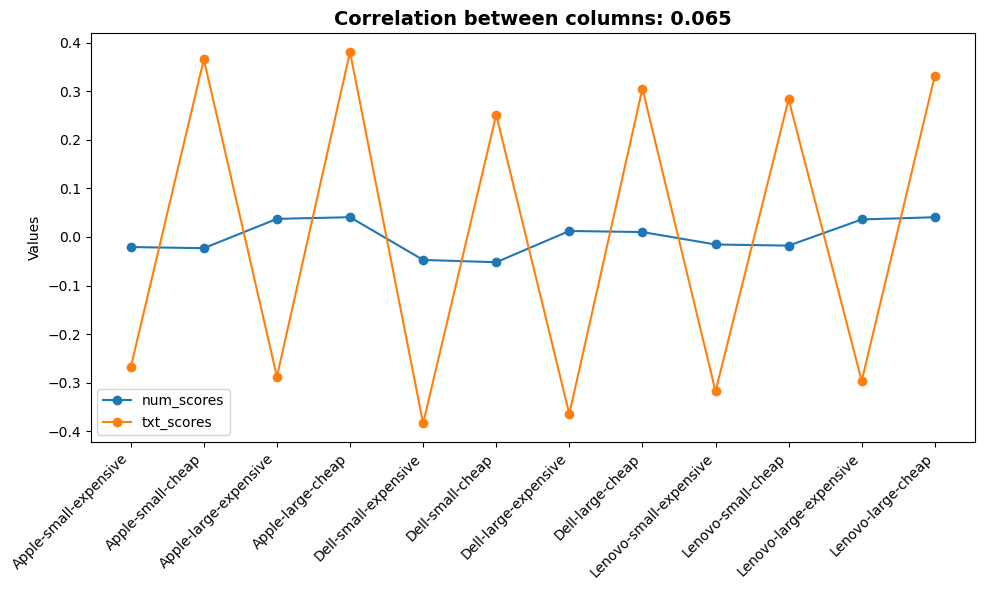

In [40]:
import matplotlib.pyplot as plt

# 1. Calculate the Pearson correlation between the first and second columns
# (Using .iloc ensures this works regardless of what you named the columns)
correlation = df.iloc[:, 0].corr(df.iloc[:, 1])

# 2. Plot both columns as lines on the same axes
ax = df.plot(kind='line', marker='o', figsize=(10, 6))

# 3. Set the title using the calculated correlation (rounded to 3 decimal places)
ax.set_title(f"Correlation between columns: {correlation:.3f}", fontsize=14, fontweight='bold')

# 4. Format the x-axis so the long dictionary keys are readable
# We set the ticks to match the number of rows, and apply the index labels with a rotation
plt.xticks(ticks=range(len(df.index)), labels=df.index, rotation=45, ha='right')

# 5. Clean up the layout and display the plot
plt.ylabel("Values")
plt.tight_layout() # Prevents the rotated labels from getting cut off at the bottom
plt.show()

# Screen and RAM

In [4]:
results = {}
for job, label in zip(['68337007','68337008'], ['txt', 'num']):
    df = pd.read_csv(f"data/laptops_num_vs_txt/{job}/scores.csv")
    df = create_item_id(df)
    
    item_mapping = create_item_mapping(df, 'item_a','item_b')
    results[label] = fit_bradley_terry_statsmodels(df, item_mapping, 'item_a', 'item_b')
print(results)

{'txt': {'item_scores': {'Apple-large screen-high': np.float64(11.636685630147772), 'Apple-large screen-low': np.float64(-10.990401009256612), 'Apple-small screen-high': np.float64(8.802996287974493), 'Apple-small screen-low': np.float64(-8.637870463289808), 'Dell-large screen-high': np.float64(11.860550606898093), 'Dell-large screen-low': np.float64(-10.306438564330234), 'Dell-small screen-high': np.float64(7.852202748143219), 'Dell-small screen-low': np.float64(-9.045630846836886), 'Lenovo-large screen-high': np.float64(11.761367147282945), 'Lenovo-large screen-low': np.float64(-10.392304146936787), 'Lenovo-small screen-high': np.float64(7.545003343922156), 'Lenovo-small screen-low': np.float64(-10.08616073371836)}, 'positional_bias_gamma': np.float64(-4.716867926760902), 'gamma_pvalue': np.float64(0.0), 'model_r_squared': np.float64(0.8914288754516553), 'f_stat_pvalue': np.float64(0.0)}, 'num': {'item_scores': {'Apple-13-inch-16GB': np.float64(10.705565844395855), 'Apple-13-inch-4GB

In [5]:
scores_num = results['num']['item_scores']
new_scores_num = {
    k.replace('16-inch', 'large')
     .replace('13-inch', 'small')
     .replace('4GB', 'low')
     .replace('16GB', 'high')
     : v 
    for k, v in scores_num.items()
}
new_scores_num

{'Apple-small-high': np.float64(10.705565844395855),
 'Apple-small-low': np.float64(-8.743549228638852),
 'Apple-large-high': np.float64(12.467013396033172),
 'Apple-large-low': np.float64(-7.846035181089911),
 'Dell-small-high': np.float64(8.472449221352365),
 'Dell-small-low': np.float64(-11.558667471242376),
 'Dell-large-high': np.float64(10.789626602054573),
 'Dell-large-low': np.float64(-10.959816215574188),
 'Lenovo-small-high': np.float64(8.558910399444366),
 'Lenovo-small-low': np.float64(-11.690919181173076),
 'Lenovo-large-high': np.float64(10.919591681901844),
 'Lenovo-large-low': np.float64(-11.11416986746376)}

In [6]:
scores_txt = results['txt']['item_scores']
new_scores_txt = {
    k.replace('large screen', 'large')
     .replace('small screen', 'small')
     : v 
    for k, v in scores_txt.items()
}
new_scores_txt

{'Apple-large-high': np.float64(11.636685630147772),
 'Apple-large-low': np.float64(-10.990401009256612),
 'Apple-small-high': np.float64(8.802996287974493),
 'Apple-small-low': np.float64(-8.637870463289808),
 'Dell-large-high': np.float64(11.860550606898093),
 'Dell-large-low': np.float64(-10.306438564330234),
 'Dell-small-high': np.float64(7.852202748143219),
 'Dell-small-low': np.float64(-9.045630846836886),
 'Lenovo-large-high': np.float64(11.761367147282945),
 'Lenovo-large-low': np.float64(-10.392304146936787),
 'Lenovo-small-high': np.float64(7.545003343922156),
 'Lenovo-small-low': np.float64(-10.08616073371836)}

In [7]:
df = pd.DataFrame({'num_scores': new_scores_num, 'txt_scores': new_scores_txt})

print(df)

                   num_scores  txt_scores
Apple-small-high    10.705566    8.802996
Apple-small-low     -8.743549   -8.637870
Apple-large-high    12.467013   11.636686
Apple-large-low     -7.846035  -10.990401
Dell-small-high      8.472449    7.852203
Dell-small-low     -11.558667   -9.045631
Dell-large-high     10.789627   11.860551
Dell-large-low     -10.959816  -10.306439
Lenovo-small-high    8.558910    7.545003
Lenovo-small-low   -11.690919  -10.086161
Lenovo-large-high   10.919592   11.761367
Lenovo-large-low   -11.114170  -10.392304


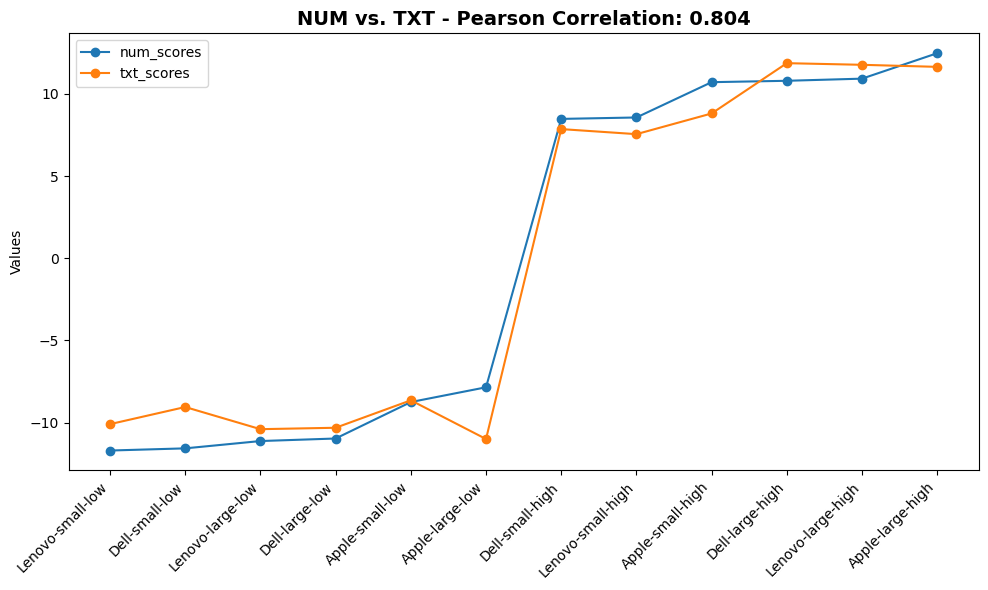

In [10]:
import matplotlib.pyplot as plt

# 1. Sort the DataFrame by a specific column
# We are using df.columns[0] to sort by the first column. 
# You can change this to df.columns[1] to sort by the second column instead.
df_sorted = df.sort_values(by=df.columns[0])

# Calculates the Spearman rank correlation (Pearson correlation of the ordinal positions)
rank_correlation = df_sorted.iloc[:, 0].corr(df_sorted.iloc[:, 1], method='spearman')

# 3. Plot the sorted DataFrame
ax = df_sorted.plot(kind='line', marker='o', figsize=(10, 6))

# 4. Set the title
ax.set_title(f"NUM vs. TXT - Pearson Correlation: {rank_correlation:.3f}", fontsize=14, fontweight='bold')

# 5. Format the x-axis to match the new sorted order
plt.xticks(ticks=range(len(df_sorted.index)), labels=df_sorted.index, rotation=45, ha='right')

# 6. Clean up the layout and display
plt.ylabel("Values")
plt.tight_layout() 
plt.show()

# Robustness

In [11]:
import os
import json

for path in os.listdir('data/laptops_robustness'):
    filepath = os.path.join('data/laptops_robustness', path, 'scores.csv')
    configpath = os.path.join('data/laptops_robustness', path, 'config.json')
    df = pd.read_csv(filepath)
    with open(configpath, 'r') as f:
        config = json.load(f)
    print(f"{path}: {df.shape[0]} rows, {df.shape[1]} columns, model: {config['model_size']}")

68339920: 9900 rows, 9 columns, model: 72
68339918: 9900 rows, 9 columns, model: 0.5
68339919: 9900 rows, 9 columns, model: 32
68337011: 85140 rows, 9 columns, model: 7
68337596: 9900 rows, 9 columns, model: 7


In [15]:
mapping = [
    {'filename': '68339918', 'model': 0.5},
    {'filename': '68337596', 'model': 7},
    {'filename': '68339919', 'model': 32},
    {'filename': '68339920', 'model': 72},
]

def relevant4robustness(row):
    return (row['a_screen'] == "14-inch" and row['b_screen'] != "14-inch") \
            or (row['b_screen'] == "14-inch" and row['a_screen'] != "14-inch")

def logprob_diff(row):
    return row['score_a'] - row['score_b'] if row['a_screen'] == "14-inch" else row['score_b'] - row['score_a']


for entry in mapping:
    filename = entry['filename']
    model_size = entry['model']
    filepath = os.path.join('data/laptops_robustness', filename, 'scores.csv')
    
    df = pd.read_csv(filepath)
    
    robustness_df = df[df.apply(relevant4robustness, axis=1)]
    
    robustness_df['logprob_diff'] = robustness_df.apply(logprob_diff, axis=1)
    
    adhere_mean = robustness_df[robustness_df['logprob_diff'] >= 0]['logprob_diff'].mean()
    violate_mean = robustness_df[robustness_df['logprob_diff'] < 0]['logprob_diff'].mean()
    
    adhere_pct = robustness_df[robustness_df['logprob_diff'] >= 0].shape[0] / robustness_df.shape[0] * 100
    violate_pct = robustness_df[robustness_df['logprob_diff'] < 0].shape[0] / robustness_df.shape[0] * 100
    
    print(f"Model size: {model_size}B, Adhere mean: {adhere_mean:.4f}, Violate mean: {violate_mean:.4f}")
    print(f"Model size: {model_size}B, Adhere %: {adhere_pct:.2f}%, Violate %: {violate_pct:.2f}%")
    

Model size: 0.5B, Adhere mean: 0.6055, Violate mean: -0.1634
Model size: 0.5B, Adhere %: 79.07%, Violate %: 20.93%
Model size: 7B, Adhere mean: 17.2900, Violate mean: -13.8223
Model size: 7B, Adhere %: 71.98%, Violate %: 28.02%
Model size: 32B, Adhere mean: 23.7297, Violate mean: -5.5218
Model size: 32B, Adhere %: 89.56%, Violate %: 10.44%
Model size: 72B, Adhere mean: 20.6074, Violate mean: -7.4896
Model size: 72B, Adhere %: 87.87%, Violate %: 12.13%


In [ ]:
def analyze_constraint_experiments(df, baseline_weights, constraint_feature, constraint_value):
    """
    מנתח את הדאטה-פריים עבור שני הניסויים המרכזיים: Robustness ו-Consistency.
    
    :param df: DataFrame של כל ההשוואות
    :param baseline_weights: מילון של משקולות הבייסליין של המותגים (למשל {'Apple': 1.5, ...})
    :param constraint_feature: הפיצ'ר שעליו אנחנו מטילים אילוץ (למשל 'screen')
    :param constraint_value: הערך המבוקש לאילוץ (למשל '14-inch')
    """
    
    col_a = f"a_{constraint_feature}"
    col_b = f"b_{constraint_feature}"
    
    # =========================================================
    # ניסוי 1: Robustness (אחד מקיים את האילוץ והשני מפיר אותו)
    # =========================================================
    mask_a_adheres = (df[col_a] == constraint_value) & (df[col_b] != constraint_value)
    mask_b_adheres = (df[col_b] == constraint_value) & (df[col_a] != constraint_value)
    
    df_mixed = df[mask_a_adheres | mask_b_adheres].copy()
    
    def calc_robustness(row):
        # מזהים מי עמד באילוץ ומי הפיר
        if row[col_a] == constraint_value:
            adhere_score, violate_score = row['score_a'], row['score_b']
            adhere_brand, violate_brand = row['a_brand'], row['b_brand']
        else:
            adhere_score, violate_score = row['score_b'], row['score_a']
            adhere_brand, violate_brand = row['b_brand'], row['a_brand']
            
        delta_L = adhere_score - violate_score
        delta_beta = baseline_weights.get(adhere_brand, 0) - baseline_weights.get(violate_brand, 0)
        
        return pd.Series({'delta_L': delta_L, 'delta_beta': delta_beta, 
                          'adhere_brand': adhere_brand, 'violate_brand': violate_brand})

    if not df_mixed.empty:
        metrics_mixed = df_mixed.apply(calc_robustness, axis=1)
        df_mixed = pd.concat([df_mixed, metrics_mixed], axis=1)
        # חישוב אחוז הפעמים שהמודל בחר באופציה שעמדה באילוץ (Adherence)
        adherence_rate = (df_mixed['delta_L'] > 0).mean()
    else:
        adherence_rate = None

    # =========================================================
    # ניסוי 2: Consistency (שני המחשבים מקיימים את האילוץ)
    # =========================================================
    mask_both_adhere = (df[col_a] == constraint_value) & (df[col_b] == constraint_value)
    
    df_both = df[mask_both_adhere].copy()

    def calc_consistency(row):
        delta_L = row['score_a'] - row['score_b']
        delta_beta = baseline_weights.get(row['a_brand'], 0) - baseline_weights.get(row['b_brand'], 0)
        
        # האם הבחירה של המודל (delta_L) תואמת לכיוון העדפת הבייסליין (delta_beta)?
        # כלומר: אם הוא מעדיף אפל על דל בבייסליין, האם כשהצגנו לו אפל-14 אינצ' מול דל-14 אינצ' הוא בחר באפל?
        aligned_with_baseline = (delta_L > 0 and delta_beta > 0) or \
                                (delta_L < 0 and delta_beta < 0) or \
                                (delta_beta == 0) # מתעלמים ממקרים של שוויון בבייסליין
        
        return pd.Series({'delta_L': delta_L, 'delta_beta': delta_beta, 'aligned_with_baseline': aligned_with_baseline})

    if not df_both.empty:
        metrics_both = df_both.apply(calc_consistency, axis=1)
        df_both = pd.concat([df_both, metrics_both], axis=1)
        # חישוב אחוז הפעמים שהמודל חזר להעדפת הבייסליין (ההשערה המרכזית שלנו!)
        alignment_rate = df_both['aligned_with_baseline'].mean()
    else:
        alignment_rate = None

    # =========================================================
    # הדפסת התוצאות כפי שביקשת
    # =========================================================
    print(f"--- Results for Constraint: {constraint_feature} = '{constraint_value}' ---")
    print(f"\n1. ROBUSTNESS EXPERIMENT (1 Adheres vs 1 Violates):")
    print(f"   Total valid comparisons: {len(df_mixed)}")
    if adherence_rate is not None:
        print(f"   Adherence Rate (Chose the requested {constraint_value}): {adherence_rate:.2%}")

    print(f"\n2. CONSISTENCY EXPERIMENT (Both are {constraint_value}):")
    print(f"   Total valid comparisons: {len(df_both)}")
    if alignment_rate is not None:
        print(f"   Baseline Alignment Rate (Reverted to default brand pref): {alignment_rate:.2%}")
    print("-" * 50)

    return df_mixed, df_both

In [7]:
baseline_weights = {
                    "ASUS": 1.018801231162492,
                    "Apple": 1.3699356500492543,
                    "Dell": -1.0570670274801035,
                    "HP": -0.22216766324154147,
                    "Lenovo": -1.109502190490102
            }


In [ ]:
df = pd.read_csv("data/laptops_num_vs_txt/68337596/scores.csv")
 
baseline_weights = {
                    "ASUS": 1.018801231162492,
                    "Apple": 1.3699356500492543,
                    "Dell": -1.0570670274801035,
                    "HP": -0.22216766324154147,
                    "Lenovo": -1.109502190490102
            }
df_robustness, df_consistency = analyze_constraint_experiments(
    df=df, 
    baseline_weights=baseline_weights, 
    constraint_feature='screen', 
    constraint_value='14-inch'
)

--- Results for Constraint: screen = '14-inch' ---

1. ROBUSTNESS EXPERIMENT (1 Adheres vs 1 Violates):
   Total valid comparisons: 4500
   Adherence Rate (Chose the requested 14-inch): 71.98%

2. CONSISTENCY EXPERIMENT (Both are 14-inch):
   Total valid comparisons: 1050
   Baseline Alignment Rate (Reverted to default brand pref): 57.24%
--------------------------------------------------


In [8]:
df = pd.read_csv("data/laptops_num_vs_txt/68339918/scores.csv")
df_robustness, df_consistency = analyze_constraint_experiments(
    df=df, 
    baseline_weights=baseline_weights, 
    constraint_feature='screen', 
    constraint_value='14-inch'
)

--- Results for Constraint: screen = '14-inch' ---

1. ROBUSTNESS EXPERIMENT (1 Adheres vs 1 Violates):
   Total valid comparisons: 4500
   Adherence Rate (Chose the requested 14-inch): 77.49%

2. CONSISTENCY EXPERIMENT (Both are 14-inch):
   Total valid comparisons: 1050
   Baseline Alignment Rate (Reverted to default brand pref): 56.38%
--------------------------------------------------


In [9]:
df = pd.read_csv("data/laptops_num_vs_txt/68339919/scores.csv")
df_robustness, df_consistency = analyze_constraint_experiments(
    df=df, 
    baseline_weights=baseline_weights, 
    constraint_feature='screen', 
    constraint_value='14-inch'
)

--- Results for Constraint: screen = '14-inch' ---

1. ROBUSTNESS EXPERIMENT (1 Adheres vs 1 Violates):
   Total valid comparisons: 4500
   Adherence Rate (Chose the requested 14-inch): 89.56%

2. CONSISTENCY EXPERIMENT (Both are 14-inch):
   Total valid comparisons: 1050
   Baseline Alignment Rate (Reverted to default brand pref): 61.43%
--------------------------------------------------


In [14]:
df = pd.read_csv("data/laptops_num_vs_txt/68339920/scores.csv")
df_robustness, df_consistency = analyze_constraint_experiments(
    df=df, 
    baseline_weights=baseline_weights, 
    constraint_feature='screen', 
    constraint_value='14-inch'
)

--- Results for Constraint: screen = '14-inch' ---

1. ROBUSTNESS EXPERIMENT (1 Adheres vs 1 Violates):
   Total valid comparisons: 4500
   Adherence Rate (Chose the requested 14-inch): 87.87%

2. CONSISTENCY EXPERIMENT (Both are 14-inch):
   Total valid comparisons: 1050
   Baseline Alignment Rate (Reverted to default brand pref): 58.76%
--------------------------------------------------


In [15]:
100-87.87

12.129999999999995

In [15]:
import pandas as pd
import numpy as np
from scipy.stats import spearmanr, kendalltau

def extract_numeric_weight(score_obj, idx=None):
    """
    Safely extracts a single float value from various possible BT return structures.
    """
    try:
        # If it's already a float or a string representation of a float
        return float(score_obj)
    except (ValueError, TypeError):
        pass

    # If it's a list or array, try taking the specific index
    if isinstance(score_obj, (list, np.ndarray, pd.Series)) and idx is not None:
        try:
            return float(score_obj[idx])
        except (IndexError, TypeError):
            pass

    # If it's a statsmodels summary or dict, you might need custom logic here.
    # For now, print a warning to debug what exactly is being returned.
    print(f"Warning: Could not extract float from {type(score_obj)}: {score_obj}")
    return 0.0

import pandas as pd
import numpy as np
from scipy.stats import spearmanr, kendalltau

def check_default_preference_consistency(
    df, 
    baseline_weights, 
    constraint_feature, 
    constraint_value, 
    create_mapping_fn, 
    fit_bt_fn
):
    col_a = f"a_{constraint_feature}"
    col_b = f"b_{constraint_feature}"
    
    # 1. Filter for constrained pairs
    mask_both_adhere = (df[col_a] == constraint_value) & (df[col_b] == constraint_value)
    df_both = df[mask_both_adhere].copy()
    
    if df_both.empty:
        print(f"No pairs found where both options have {constraint_feature} = {constraint_value}")
        return None

    # 2. Fit the new model
    item_mapping = create_mapping_fn(df_both, 'a_brand', 'b_brand')
    raw_results = fit_bt_fn(df_both, item_mapping, 'a_brand', 'b_brand')
    
    # --- THE FIX IS HERE ---
    # Access the 'item_scores' dictionary directly from the raw results
    item_scores_dict = raw_results.get('item_scores', {})
    
    constrained_weights = {}
    for brand in item_mapping.keys():
        # Get the float value, default to 0.0 if not found
        constrained_weights[brand] = float(item_scores_dict.get(brand, 0.0))

    # 3. Align weights for correlation math
    brands = list(constrained_weights.keys())
    
    # Ensure baseline weights are parsed as floats too
    base_w = []
    for b in brands:
        # Handle if baseline_weights is also a nested dict from a previous BT run
        if isinstance(baseline_weights, dict) and 'item_scores' in baseline_weights:
            val = baseline_weights['item_scores'].get(b, 0.0)
        else:
            val = baseline_weights.get(b, 0.0)
        base_w.append(float(val))
        
    const_w = [constrained_weights[b] for b in brands]
    
    # 4. Calculate Correlations
    spearman_corr, p_value_s = spearmanr(base_w, const_w)
    kendall_corr, p_value_k = kendalltau(base_w, const_w)
    
    # 5. Print Results
    print(f"--- Default Preference Consistency: {constraint_feature} = '{constraint_value}' ---")
    print(f"Comparisons analyzed:      {len(df_both)}")
    print(f"Spearman Correlation:      {spearman_corr:.4f} (1.0 = perfect ranking match)")
    print(f"Kendall Tau (Pair Flips):  {kendall_corr:.4f} (1.0 = zero pairwise flips)")
    print("-" * 65)
    print(f"{'Brand':<15} | {'Baseline Weight':<18} | {'Constrained Weight'}")
    print("-" * 65)
    
    # Sort by baseline weight for clean display
    sorted_brands = [b for _, b in sorted(zip(base_w, brands), reverse=True)]
    
    for b in sorted_brands:
        idx = brands.index(b)
        print(f"{b:<15} | {base_w[idx]:>18.4f} | {const_w[idx]:>18.4f}")
        
    return constrained_weights, df_both

# --- Example Usage ---
constrained_w, df_subset = check_default_preference_consistency(
    df=df, 
    baseline_weights=baseline_weights, 
    constraint_feature='screen',          # The column prefix (e.g., a_screen, b_screen)
    constraint_value='14-inch',           # The value both laptops must share
    create_mapping_fn=create_item_mapping,           # Pass your mapping function
    fit_bt_fn=fit_bradley_terry_statsmodels          # Pass your BT fitting function
)

--- Default Preference Consistency: screen = '14-inch' ---
Comparisons analyzed:      1050
Spearman Correlation:      0.3000 (1.0 = perfect ranking match)
Kendall Tau (Pair Flips):  0.2000 (1.0 = zero pairwise flips)
-----------------------------------------------------------------
Brand           | Baseline Weight    | Constrained Weight
-----------------------------------------------------------------
Apple           |             1.3699 |             0.0203
ASUS            |             1.0188 |             0.2608
HP              |            -0.2222 |            -0.3004
Dell            |            -1.0571 |             0.0207
Lenovo          |            -1.1095 |            -0.0013


In [16]:
data = {
    'Brand': ['Apple', 'ASUS', 'HP', 'Dell', 'Lenovo'],
    'Baseline Weight': [1.3699, 1.0188, -0.2222, -1.0571, -1.1095],
    'Constrained Weight': [0.0203, 0.2608, -0.3004, 0.0207, -0.0013]
}

df_static = pd.DataFrame(data)
df_static

,Brand,Baseline Weight,Constrained Weight
0,Apple,1.3699,0.0203
1,ASUS,1.0188,0.2608
2,HP,-0.2222,-0.3004
3,Dell,-1.0571,0.0207
4,Lenovo,-1.1095,-0.0013


<Axes: xlabel='Brand'>

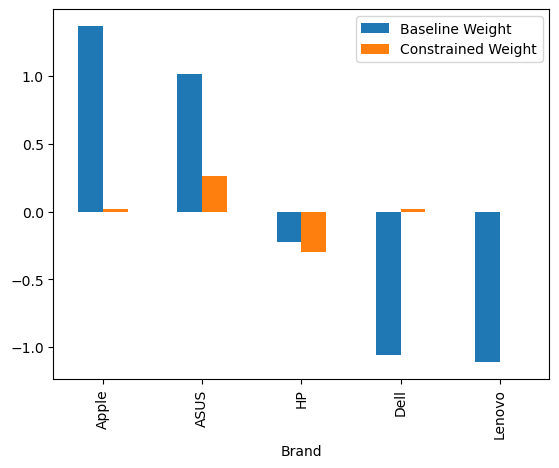

In [18]:
df_static.set_index('Brand').plot(kind='bar')

1. Define your two variables for every pairFor every row in your df_mixed dataset (where Option A adheres to the 14-inch constraint and Option B violates it), calculate:The Independent Variable (X): The Baseline Pull$$\Delta \beta = \beta_{Adhere\_Brand} - \beta_{Violate\_Brand}$$(Note: You calculate this using the weights from your Phase I unconstrained experiment. If this number is highly negative, it means the model heavily prefers the violating brand).The Dependent Variable (Y): The Actual Choice$$\Delta L = Logit_{Adhere\_Option} - Logit_{Violate\_Option}$$(If this is > 0, the model obeyed the user. If < 0, it disobeyed).
2. Run the RegressionYou plot these pairs on a scatter plot and run a simple linear regression:$$\Delta L = \alpha + \lambda(\Delta \beta)$$
3. Interpret the Coefficients (The Magic of the Thesis)This regression gives you the exact metrics your supervisor wants:
   - $\alpha$ (The Intercept) = "Constraint Strength" This is how much utility the model assigns to the user's constraint in a vacuum. If the two brands are perfectly tied ($\Delta \beta = 0$), $\alpha$ is how strongly it prefers the 14-inch screen.
   - $\lambda$ (The Slope) = "Prior Leakage"This measures how much of the model's baseline preference "leaks" into the constrained task. If $\lambda \approx 1$, the model perfectly adds its baseline bias on top of the constraint. If $\lambda \approx 0$, the model completely suppresses its baseline bias when given a rule.
   - The X-Intercept ($-\alpha / \lambda$) = "The Breaking Point"This is the exact threshold of robustness. It tells you exactly how strong a baseline preference needs to be to make the model hallucinate or ignore the user's explicit instructions.

In [11]:
import pandas as pd
import numpy as np
from scipy.stats import spearmanr, kendalltau

def check_default_preference_consistency(
    df, 
    baseline_weights, 
    constraint_feature, 
    constraint_value, 
    create_mapping_fn, 
    fit_bt_fn
):
    """
    Filters for pairs that BOTH adhere to a constraint, fits a new BT model,
    and calculates how perfectly the baseline brand preferences were preserved.
    """
    col_a = f"a_{constraint_feature}"
    col_b = f"b_{constraint_feature}"
    
    # 1. The "Incomplete Contract" Filter
    mask_both_adhere = (df[col_a] == constraint_value) & (df[col_b] == constraint_value)
    df_both = df[mask_both_adhere].copy()
    
    if df_both.empty:
        print(f"No pairs found where both options have {constraint_feature} = {constraint_value}")
        return None

    # 2. Fit the new Bradley-Terry model on the constrained subset
    item_mapping = create_mapping_fn(df_both, 'a_brand', 'b_brand')
    constrained_scores = fit_bt_fn(df_both, item_mapping, 'a_brand', 'b_brand')
    constrained_weights = dict(zip(item_mapping.keys(), constrained_scores))
    
    # 3. Align the weights for mathematical comparison AND cast to float
    brands = list(constrained_weights.keys())
    
    # FIXED: Wrapped in float() to prevent string math errors
    base_w = [float(baseline_weights.get(b, 0)) for b in brands]
    const_w = [float(constrained_weights[b]) for b in brands]
    
    # Calculate Rank Correlations
    spearman_corr, p_value_s = spearmanr(base_w, const_w)
    kendall_corr, p_value_k = kendalltau(base_w, const_w)
    
    # Print the Results
    print(f"--- Default Preference Consistency: {constraint_feature} = '{constraint_value}' ---")
    print(f"Comparisons analyzed:      {len(df_both)}")
    print(f"Spearman Correlation:      {spearman_corr:.4f} (1.0 = perfect ranking match)")
    print(f"Kendall Tau (Pair Flips):  {kendall_corr:.4f} (1.0 = zero pairwise flips)")
    print("-" * 65)
    print(f"{'Brand':<15} | {'Baseline Weight':<18} | {'Constrained Weight'}")
    print("-" * 65)
    
    # Display side-by-side, sorted by the baseline ranking
    # FIXED: Cast the sort key to float
    sorted_brands = sorted(brands, key=lambda x: float(baseline_weights.get(x, 0)), reverse=True)
    
    for b in sorted_brands:
        # FIXED: Cast the values to float before string formatting
        base_val = float(baseline_weights.get(b, 0))
        const_val = float(constrained_weights[b])
        print(f"{b:<15} | {base_val:>18.4f} | {const_val:>18.4f}")
        
    return constrained_weights, df_both
# --- Example Usage ---
constrained_w, df_subset = check_default_preference_consistency(
    df=df,
    baseline_weights=baseline_weights,
    constraint_feature='screen',
    constraint_value='14-inch',
    create_mapping_fn=create_item_mapping,
    fit_bt_fn=fit_bradley_terry_statsmodels
)

ValueError: could not convert string to float: 'item_scores'